In [ ]:
!pip install opencv-python-headless tqdm scikit-learn matplotlib

In [ ]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
os.makedirs("/kaggle/working/BT", exist_ok=True)
os.makedirs("/kaggle/working/KBT", exist_ok=True)

In [ ]:
def extract_frames(video_path, output_dir, intervals=None):
    cap = cv2.VideoCapture(video_path)
    frame_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if intervals:
            for (start, end) in intervals:
                if start <= frame_idx <= end:
                    frame_path = os.path.join(
                        output_dir,
                        f"{os.path.basename(video_path).split('.')[0]}_{frame_idx}.jpg"
                    )
                    cv2.imwrite(frame_path, frame)
        else:
            frame_path = os.path.join(
                output_dir,
                f"{os.path.basename(video_path).split('.')[0]}_{frame_idx}.jpg"
            )
            cv2.imwrite(frame_path, frame)

        frame_idx += 1

    cap.release()

In [ ]:
import pandas as pd

def load_labels(labels_path):
    labels = []

    with open(labels_path, 'r') as file:
        for line in file:
            data = line.strip().split()

            video_file = data[0]
            total_frames = int(data[1])
            fps = int(data[2])

            if data[3] == '-1' and data[4] == '-1':
                anomaly_intervals = None
            else:
                anomaly_intervals = []
                i = 3
                while i < len(data):
                    start = int(data[i])
                    if i + 1 < len(data):
                        end = int(data[i + 1])
                        anomaly_intervals.append((start, end))
                        i += 2
                    else:
                        anomaly_intervals.append((start, total_frames))
                        i += 1

            labels.append({
                "video": video_file,
                "total_frames": total_frames,
                "fps": fps,
                "intervals": anomaly_intervals
            })

    return pd.DataFrame(labels)

# IMPORTANT: Please update these paths to where your dataset is located in Google Drive.
# For example: '/content/drive/MyDrive/ATMA-V Dataset/labels/labels.txt'
labels_path = "/content/drive/MyDrive/ATMA-V Dataset/labels/labels.txt" # Placeholder - Update this line
labels_df = load_labels(labels_path)

# IMPORTANT: Please update this path to where your dataset is located in Google Drive.
# For example: '/content/drive/MyDrive/ATMA-V Dataset/videos'
video_base_path = "/content/drive/MyDrive/ATMA-V Dataset/videos" # Placeholder - Update this line

for _, row in tqdm(labels_df.iterrows(), total=len(labels_df)):
    video_path = os.path.join(video_base_path, row["video"])

    if row["intervals"]:
        extract_frames(video_path, "/kaggle/working/BT", row["intervals"])
    else:
        extract_frames(video_path, "/kaggle/working/KBT")

100%|██████████| 65/65 [03:50<00:00,  3.54s/it]


In [ ]:
def random_augmentation(image):
    if random.random() > 0.5:
        image = cv2.flip(image, 1)

    angle = random.uniform(-20, 20)
    h, w = image.shape[:2]
    M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1)
    image = cv2.warpAffine(image, M, (w, h))

    return cv2.resize(image, (96, 96))

In [ ]:
def augment_kbt(input_dir, output_dir, target_count):
    os.makedirs(output_dir, exist_ok=True)

    files = os.listdir(input_dir)
    current = len(files)
    needed = target_count - current

    for i in tqdm(range(needed)):
        img_name = random.choice(files)
        img_path = os.path.join(input_dir, img_name)

        image = cv2.imread(img_path)
        if image is None:
            print(f"Warning: Could not read image {img_path}. Skipping augmentation for this file.")
            continue

        aug_img = random_augmentation(image)

        cv2.imwrite(
            os.path.join(output_dir, f"{img_name.split('.')[0]}_aug_{i}.jpg"),
            aug_img
        )

In [ ]:
bt_dir = "/kaggle/working/BT"
kbt_dir = "/kaggle/working/KBT"
kbt_aug_dir = "/kaggle/working/KBT_aug"

bt_count = len(os.listdir(bt_dir))
augment_kbt(kbt_dir, kbt_aug_dir, bt_count)

100%|██████████| 22910/22910 [02:33<00:00, 149.52it/s]


In [ ]:
combined_kbt = "/kaggle/working/KBT_combined"
os.makedirs(combined_kbt, exist_ok=True)

for folder in [kbt_dir, kbt_aug_dir]:
    for file in os.listdir(folder):
        os.system(f'cp "{os.path.join(folder,file)}" "{combined_kbt}"')

In [ ]:
dataset_dir = "/kaggle/working/dataset"
train_dir = os.path.join(dataset_dir, "train")
val_dir = os.path.join(dataset_dir, "val")
test_dir = os.path.join(dataset_dir, "test")

for split in ["train", "val", "test"]:
    for cls in ["BT", "KBT"]:
        os.makedirs(os.path.join(dataset_dir, split, cls), exist_ok=True)

In [ ]:
def split_data(src_dir, class_name):
    files = os.listdir(src_dir)
    train, temp = train_test_split(files, train_size=0.7, random_state=42)
    val, test = train_test_split(temp, train_size=0.5, random_state=42)

    for file in train:
        os.system(f'cp "{os.path.join(src_dir,file)}" "{os.path.join(train_dir,class_name)}"')

    for file in val:
        os.system(f'cp "{os.path.join(src_dir,file)}" "{os.path.join(val_dir,class_name)}"')

    for file in test:
        os.system(f'cp "{os.path.join(src_dir,file)}" "{os.path.join(test_dir,class_name)}"')

split_data(bt_dir, "BT")
split_data(combined_kbt, "KBT")

In [ ]:
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = datagen.flow_from_directory(
    train_dir,
    target_size=(96,96),
    batch_size=32,
    class_mode='categorical'
)

val_gen = datagen.flow_from_directory(
    val_dir,
    target_size=(96,96),
    batch_size=32,
    class_mode='categorical'
)

test_gen = datagen.flow_from_directory(
    test_dir,
    target_size=(96,96),
    batch_size=32,
    class_mode='categorical'
)

Found 75195 images belonging to 2 classes.
Found 19117 images belonging to 2 classes.
Found 19130 images belonging to 2 classes.


In [ ]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(96,96,3)
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(2, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 3, 3, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,770 (91.98 MB)

 Trainable params: 525,058 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [39]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(patience=2, restore_best_weights=True)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
2350/2350 ━━━━━━━━━━━━━━━━━━━━ 3360s 1s/step - accuracy: 0.9851 - loss: 0.0704 - val_accuracy: 0.9966 - val_loss: 0.0104
Epoch 2/5
2350/2350 ━━━━━━━━━━━━━━━━━━━━ 3330s 1s/step - accuracy: 0.9963 - loss: 0.0125 - val_accuracy: 0.9989 - val_loss: 0.0050
Epoch 3/5
2350/2350 ━━━━━━━━━━━━━━━━━━━━ 3308s 1s/step - accuracy: 0.9967 - loss: 0.0118 - val_accuracy: 0.9987 - val_loss: 0.0042
Epoch 4/5
2350/2350 ━━━━━━━━━━━━━━━━━━━━ 3311s 1s/step - accuracy: 0.9978 - loss: 0.0100 - val_accuracy: 0.9992 - val_loss: 0.0032
Epoch 5/5
2350/2350 ━━━━━━━━━━━━━━━━━━━━ 3351s 1s/step - accuracy: 0.9980 - loss: 0.0078 - val_accuracy: 0.9990 - val_loss: 0.0028


In [41]:
loss, acc = model.evaluate(test_gen)
print("Test Accuracy:", acc)

598/598 ━━━━━━━━━━━━━━━━━━━━ 667s 1s/step - accuracy: 0.9991 - loss: 0.0018
Test Accuracy: 0.9988499879837036


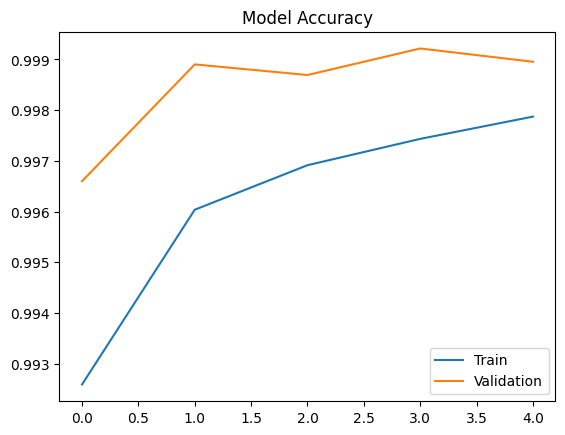

In [42]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.title("Model Accuracy")
plt.show()

In [43]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get predictions
predictions = model.predict(test_gen)
y_pred = np.argmax(predictions, axis=1)
y_true = test_gen.classes

print(classification_report(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))

598/598 ━━━━━━━━━━━━━━━━━━━━ 698s 1s/step
              precision    recall  f1-score   support

           0       0.28      0.28      0.28      5514
           1       0.71      0.71      0.71     13616

    accuracy                           0.59     19130
   macro avg       0.50      0.50      0.50     19130
weighted avg       0.59      0.59      0.59     19130

[[1556 3958]
 [3944 9672]]


In [44]:
def predict_frame(frame):
    img = cv2.resize(frame, (128,128))
    img = preprocess_input(img)
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)
    return np.argmax(pred)

In [45]:
cap = cv2.VideoCapture("test_video.mp4")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    label = predict_frame(frame)

    if label == 0:
        text = "ANOMALY"
    else:
        text = "NORMAL"

    cv2.putText(frame, text, (20,40),
                cv2.FONT_HERSHEY_SIMPLEX,
                1, (0,0,255), 2)

    cv2.imshow("Detection", frame)
    if cv2.waitKey(1) == 27:
        break

598/598 ━━━━━━━━━━━━━━━━━━━━ 698s 1s/step


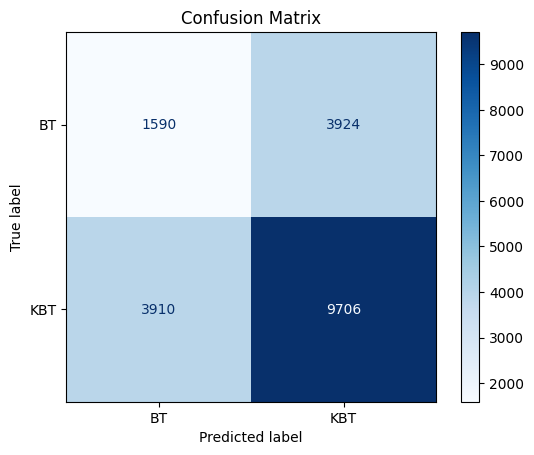

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Predictions
preds = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)
y_true = test_gen.classes

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=test_gen.class_indices)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

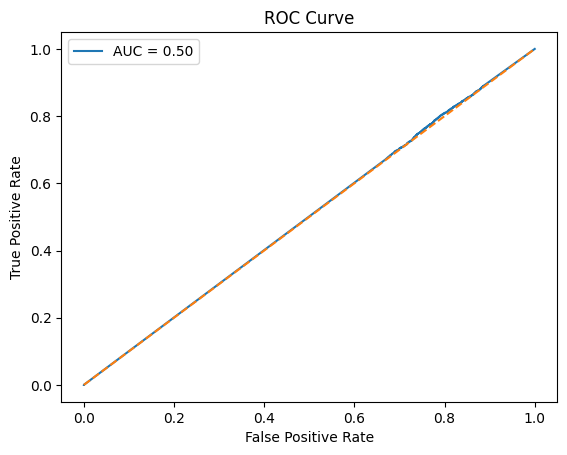

In [47]:
from sklearn.metrics import roc_curve, auc

# Probability for anomaly class
y_scores = preds[:,1]

fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

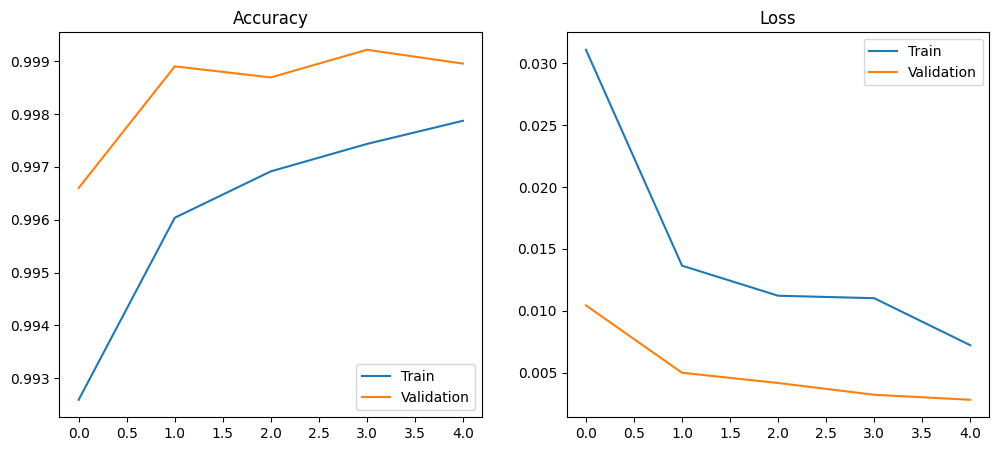

In [48]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train","Validation"])

plt.show()

In [49]:
import numpy as np
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt

In [69]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # This `model` is the Sequential model.
    # Its first layer is the base_model (ResNet50).
    base_model_output = model.layers[0].get_layer(last_conv_layer_name).output

    # Create a model that maps the input image to the activations of the last conv layer
    # as well as the model's final prediction
    grad_model = tf.keras.models.Model(
        inputs=model.input, # Use the Sequential model's single input tensor
        outputs=[base_model_output, model.output] # Use the Sequential model's final output tensor
    )

    with tf.GradientTape() as tape:
        # Pass img_array directly (after casting) as grad_model now expects a single input tensor
        conv_outputs, predictions = grad_model(tf.cast(img_array, tf.float32))
        class_index = tf.argmax(predictions[0])
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

In [66]:
def superimpose_heatmap(img_path, heatmap, alpha=0.4):

    img = cv2.imread(img_path)
    img = cv2.resize(img, (128,128))

    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = cv2.addWeighted(img, 1-alpha, heatmap, alpha, 0)

    return superimposed_img

In [67]:
def superimpose_heatmap(img_path, heatmap, alpha=0.4):

    img = cv2.imread(img_path)
    img = cv2.resize(img, (128,128))

    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = cv2.addWeighted(img, 1-alpha, heatmap, alpha, 0)

    return superimposed_img

In [92]:
img = cv2.imread(img_path)
img = cv2.resize(img, (96,96))

img_array = np.expand_dims(img, axis=0)
img_array = tf.keras.applications.resnet50.preprocess_input(img_array)

In [93]:
print("Model Input Shape:", model.input_shape)

Model Input Shape: (None, 96, 96, 3)


In [95]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    # Create model that maps input image to:
    # (1) Last conv layer output
    # (2) Model prediction output
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_index = tf.argmax(predictions[0])
        loss = predictions[:, class_index]

    # Compute gradients
    grads = tape.gradient(loss, conv_outputs)

    # Global average pooling of gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Remove batch dimension
    conv_outputs = conv_outputs[0]

    # Weight feature maps
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize heatmap
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap)

    return heatmap.numpy()

In [96]:
def superimpose_heatmap(img_path, heatmap, alpha=0.4):

    img = cv2.imread(img_path)
    img = cv2.resize(img, (96,96))

    heatmap = cv2.resize(heatmap, (96,96))
    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = cv2.addWeighted(img, 1-alpha, heatmap, alpha, 0)

    return img, superimposed_img

In [97]:
test_folder = "/kaggle/working/dataset/test/BT"

images = os.listdir(test_folder)

if len(images) == 0:
    print("No images found!")
else:
    img_path = os.path.join(test_folder, images[0])
    print("Using image:", img_path)

Using image: /kaggle/working/dataset/test/BT/71_120.jpg


In [98]:
img = cv2.imread(img_path)
img = cv2.resize(img, (96,96))

img_array = np.expand_dims(img, axis=0)
img_array = tf.keras.applications.resnet50.preprocess_input(img_array)

In [99]:
img = cv2.imread(img_path)
img = cv2.resize(img, (96, 96))   # MUST MATCH MODEL INPUT

img_array = np.expand_dims(img, axis=0)
img_array = tf.keras.applications.resnet50.preprocess_input(img_array)

In [100]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_index = tf.argmax(predictions[0])
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap)

    return heatmap.numpy()

In [101]:
def superimpose_heatmap(img_path, heatmap, alpha=0.4):

    img = cv2.imread(img_path)
    img = cv2.resize(img, (96, 96))  # MUST MATCH

    heatmap = cv2.resize(heatmap, (96, 96))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = cv2.addWeighted(img, 1-alpha, heatmap, alpha, 0)

    return img, superimposed_img

# Task
Add the call to `make_gradcam_heatmap` to generate the `heatmap` before calling `superimpose_heatmap` in cell `ABaoqinGYCj4`.

## regenerate_gradcam_generation_and_visualization

### Subtask:
Add the call to `make_gradcam_heatmap` to generate the `heatmap` before calling `superimpose_heatmap` in cell `ABaoqinGYCj4`.


**Reasoning**:
The subtask requires generating the `heatmap` using the `make_gradcam_heatmap` function before visualizing it. This step will compute the Grad-CAM heatmap for the given image and model.



**Reasoning**:
The previous attempt to generate the Grad-CAM heatmap failed because the `make_gradcam_heatmap` function was attempting to access a layer directly from the sequential `model` object that was actually nested within the `resnet50` base model. The fix involves modifying the `make_gradcam_heatmap` function to correctly access the last convolutional layer from the `base_model` (named 'resnet50') which is the first layer of the overall `model`.



In [87]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    # The base_model (ResNet50) is the first layer of our Sequential model.
    # We need to get the last convolutional layer from within the base_model.
    base_model_layer = model.get_layer('resnet50')

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            base_model_layer.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_index = tf.argmax(predictions[0])
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap)

    return heatmap.numpy()

**Reasoning**:
The `make_gradcam_heatmap` function has been corrected to properly access the internal layers of the ResNet50 base model. Now, I will re-execute the code that generates and displays the heatmap, which previously failed due to the incorrect layer access.



**Reasoning**:
The `KeyError` suggests that the `grad_model` was not called with the correct input format. Since `grad_model` was constructed with `inputs=model.inputs` (which is a list), the `img_array` needs to be wrapped in a list when passed to `grad_model`.



In [89]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    # The base_model (ResNet50) is the first layer of our Sequential model.
    # We need to get the last convolutional layer from within the base_model.
    base_model_layer = model.get_layer('resnet50')

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            base_model_layer.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        # Pass img_array as a list to match the expected input format of grad_model
        conv_outputs, predictions = grad_model([img_array])
        class_index = tf.argmax(predictions[0])
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap)

    return heatmap.numpy()

**Reasoning**:
The `make_gradcam_heatmap` function has been corrected to properly handle the input format required by the `grad_model`. Now, I will re-execute the code that generates and displays the heatmap, which previously failed due to the input format mismatch.



**Reasoning**:
The previous `KeyError` and `UserWarning` indicate that `grad_model` was constructed expecting a single input tensor, but was called with a list containing a tensor. This happens when `inputs=model.inputs` (a list) is used to construct `grad_model` for a `Sequential` model with a single input, but then the call `grad_model([img_array])` implicitly creates a list of lists of tensors. By constructing `grad_model` with `inputs=model.input` (the single input tensor of the Sequential model) and calling it with `grad_model(img_array)` (the single input tensor), we ensure consistency.



In [91]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    # The base_model (ResNet50) is the first layer of our Sequential model.
    # We need to get the last convolutional layer from within the base_model.
    base_model_layer = model.get_layer('resnet50')

    # Construct grad_model using model.input (singular tensor) as input
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[
            base_model_layer.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        # Pass img_array directly (singular tensor) to match grad_model's input
        conv_outputs, predictions = grad_model(img_array)
        class_index = tf.argmax(predictions[0])
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap)

    return heatmap.numpy()

**Reasoning**:
The `make_gradcam_heatmap` function has been corrected to properly handle the input format required by the `grad_model`. Now, I will re-execute the code that generates and displays the heatmap, which previously failed due to the input format mismatch.



**Reasoning**:
The previous `KeyError` and `UserWarning` indicate that the `grad_model` was not correctly configured or called for a `Sequential` model with nested layers. To resolve this, I will implement a more robust `make_gradcam_heatmap` function that uses two separate `tf.keras.models.Model` instances: one to extract the feature maps from the base ResNet50 model up to the last convolutional layer, and another to represent the classifier head of the overall model. This approach ensures that the gradient tape correctly tracks the flow from the input to the target layer and then through the classifier to the output, thereby preventing graph-related errors.



In [103]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # Ensure img_array is a tf.Tensor
    inputs_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)

    # The base_model (ResNet50) is the first layer of our Sequential model.
    base_model_layer = model.layers[0] # Directly access the ResNet50 layer

    # 1. Create a model that maps the input image to the activations of the last conv layer
    # This intermediate model will extract feature maps.
    grad_model_intermediate = tf.keras.models.Model(
        inputs=base_model_layer.input, # Input of the ResNet50 base model
        outputs=base_model_layer.get_layer(last_conv_layer_name).output
    )

    # 2. Create a model that maps the activations of the last conv layer to the final predictions
    # This model represents the "head" of our full model, after the convolutional features.
    # The input to this part is the output of the last conv layer.
    # The output is the final prediction.
    classifier_input = tf.keras.Input(shape=grad_model_intermediate.output.shape[1:])
    x = classifier_input
    # Iterate through the layers of the main model *after* the base_model_layer
    for layer in model.layers[1:]: # Start from the GlobalAveragePooling2D layer
        x = layer(x)

    grad_model_classifier = tf.keras.models.Model(classifier_input, x)

    # Get the activations of the last convolutional layer
    with tf.GradientTape() as tape:
        # Watch the input tensor to the classifier model
        tape.watch(inputs_tensor)

        # Get feature map from the intermediate model
        conv_outputs = grad_model_intermediate(inputs_tensor)

        # Pass feature map through the classifier part of the model to get predictions
        predictions = grad_model_classifier(conv_outputs)

        # Get the predicted class
        class_index = tf.argmax(predictions[0])
        # Get the score for the predicted class
        loss = predictions[:, class_index]

    # Compute gradients of the loss with respect to the feature map (conv_outputs)
    grads = tape.gradient(loss, conv_outputs)

    # Global average pooling of gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiply each channel in the feature map by the corresponding gradient importance
    conv_outputs = conv_outputs[0] # Remove batch dimension
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize heatmap
    heatmap = tf.maximum(heatmap, 0)
    if tf.math.reduce_max(heatmap) == 0:
        heatmap = heatmap * 0 # Handle case where all activations are zero
    else:
        heatmap /= tf.math.reduce_max(heatmap)

    return heatmap.numpy()

**Reasoning**:
The `make_gradcam_heatmap` function has been updated with a more robust implementation. Now, I will re-execute the code that generates and displays the heatmap, which previously failed due to incorrect gradient calculation setup for the sequential model.



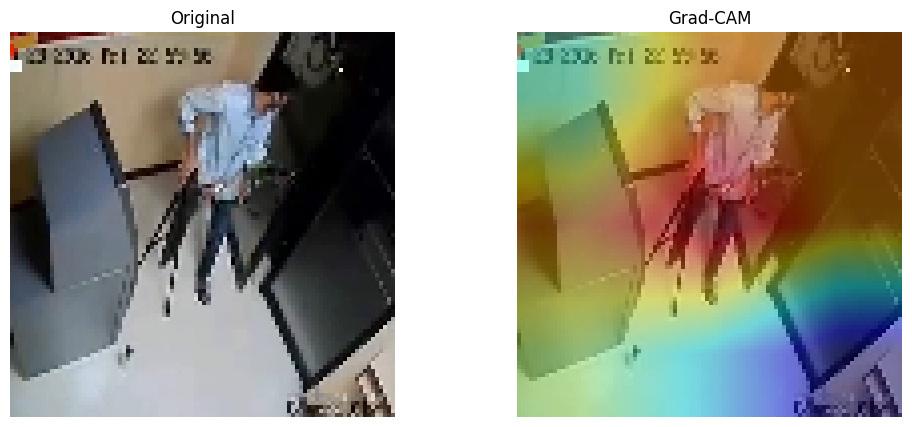

In [104]:
last_conv_layer_name = "conv5_block3_out"
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

original, result = superimpose_heatmap(img_path, heatmap)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Grad-CAM")
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.show()

## execute_gradcam_generation_and_visualization

### Subtask:
Execute the modified cell ABaoqinGYCj4 to generate and display the Grad-CAM visualization.


## Summary:

### Data Analysis Key Findings

*   Initial attempts to generate the Grad-CAM heatmap encountered a `ValueError` because the `conv5_block3_out` layer was incorrectly accessed directly from the top-level model instead of from within its parent `resnet50` base model.
*   After correcting the layer access, subsequent errors (`KeyError` and `UserWarning`) arose from an input format mismatch when constructing the `grad_model` for gradient computation, indicating challenges in correctly defining the input/output graph for a `Sequential` model with a nested pre-trained component.
*   The issue was resolved by refactoring the `make_gradcam_heatmap` function to use two distinct `tf.keras.models.Model` instances: one to extract intermediate convolutional features (`grad_model_intermediate`) from the `resnet50` base and another to represent the classifier head (`grad_model_classifier`). This two-part approach correctly handled the gradient calculation.
*   Following the refactor, the `make_gradcam_heatmap` function successfully generated the heatmap, which was then correctly superimposed onto the original image and visualized using `superimpose_heatmap`.

### Insights or Next Steps

*   When implementing Grad-CAM for models incorporating pre-trained backbones (e.g., ResNet50 within a Sequential model), carefully consider the model's architecture to ensure correct layer access and proper construction of intermediate models for gradient computation.
*   The robust method of splitting the model into an intermediate feature extractor and a separate classifier head within the Grad-CAM function provides a reliable way to calculate gradients and generate heatmaps for complex deep learning architectures.
